In [1]:
# from google.colab import drive
import torch
import sys
import numpy as np
import math
import time
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup
# drive.mount('/content/gdrive', force_remount=True)


#base_dir = "/content/gdrive/MyDrive/Junior/Second Semester/CS 6787 - Advanced ML Systems/Final Project"
# base_dir = "/content/gdrive/MyDrive/Final Project"
base_dir = ""
# sys.path.append(base_dir)

device = torch.device("cuda" if torch.cuda.is_available()
                else ("mps" if torch.backends.mps.is_available()
                else "cpu"))
#device = torch.device("meta")
print(F"Device set to {device}")
print("Loading GPT2 model...")

Device set to cuda
Loading GPT2 model...


In [2]:
print("Importing libraries...")

Importing libraries...


In [6]:
!pwd

/content


In [7]:
import sys
import importlib

# 1. Force remove the old module from the cache
if 'GPT2' in sys.modules:
    del sys.modules['GPT2']

In [8]:
import os
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

In [2]:
import importlib
import Datasets.DataLoader as DataLoader_Lib
# from Models.GPT_Model import GPT2, GPTConfig
from Models.LagBehind_Model import GPT2_Lag
import Models.GPT_Model as GPT_Model
import Models.LagBehind_Model as LagBehind_Model

importlib.reload(GPT_Model)
importlib.reload(LagBehind_Model)
importlib.reload(DataLoader_Lib)

from Models.GPT_Model import GPT2, GPTConfig
from Models.LagBehind_Model import GPT2_Lag
from Models.Baseline_Model.GPT2_Baseline import GPT2_Baseline

from Datasets.DataLoader import TinyShakespeareDataLoader, TinyStoriesDataLoader, CombinedBinDataLoader

In [3]:
from Models.Configs import BaselineConfig, LagBehindConfig

In [4]:
from Models.Configs import TrainConfig

In [5]:
B = 32 # Adjust batch size based on your Colab GPU memory
SL = 256
config = LagBehindConfig(num_heads = 6,
  num_layers = 6,
  vocab_size = 50257,
  embedding_dim = 768,
  block_size = SL,
  lag_behind = 1,
  dropout = .1)

config2 = LagBehindConfig()

model = GPT2_Lag(config2, device)
model.to(device)

train_config = TrainConfig()
optimizer = train_config.make_optimizer(model)
scheduler = train_config.make_scheduler(optimizer)
grad_scaler = train_config.make_scaler()


# Config = GPTConfig(num_heads = 12,
#   num_layers = 12,
#   vocab_size = 50257,
#   embedding_dim = 768,
#   block_size = block_size,
#   lag_behind = 1,
#   dropout = .1,
#   pad_token_id=loader.pad_token())

# model = GPT2_Lag(Config, device)
# model.to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [6]:
B = 512
SL = config2.block_size


In [10]:
print(SL)

512


In [7]:
from Datasets.DataLoader import CombinedBinDataLoader

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!cp "/content/drive/MyDrive/fineweb_1B.bin" "/content/fineweb_1B.bin"

In [10]:
train_loader, val_loader = CombinedBinDataLoader.create_loaders('/content/fineweb_1B.bin', train_config.batch_per_iter, SL, train_config)

Initialized loader with 57,983 chunks of size 16385.
Initialized loader with 3,052 chunks of size 16385.


In [11]:
import math

In [12]:
print(torch.__version__)

2.10.0+cu128


In [14]:
train_loader.idx

1

In [13]:
def save_checkpoint(model, optimizer, step, loss, path):
    torch.save({
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['step'], checkpoint['loss']

In [14]:
@torch.no_grad()
def estimate_loss(model, loader, device, eval_iters=10):
    model.eval()
    fwd_losses = torch.zeros(eval_iters)
    bwd_losses = torch.zeros(eval_iters)
    loader.cursor = 0

    for k in range(eval_iters):
        x, y, _ = loader.get_data()
        x, y = x.to(device), y.to(device)

        logits_fwd, logits_lag, _ = model(x, y)

        V         = model.config.vocab_size
        skip_dist = model.config.lag_behind
        half      = x.size(0) // 2

        fwd_losses[k] = F.cross_entropy(
            logits_fwd.view(-1, V),
            y[:half].view(-1)
        ).item()

        bwd_targets = x[half:, :-skip_dist]
        bwd_logits  = logits_lag[:, skip_dist:]
        bwd_losses[k] = F.cross_entropy(
            bwd_logits.reshape(-1, V),
            bwd_targets.reshape(-1)
        ).item()

    model.train()
    avg_fwd = fwd_losses.mean().item()
    avg_bwd = bwd_losses.mean().item()
    ppl     = torch.exp(torch.tensor(avg_fwd)).item()
    return avg_fwd, ppl, avg_bwd

# def get_lr(step, num_steps_train, warmup_steps=1000, max_lr=3e-4, min_lr=3e-5):
#     if step < warmup_steps:
#         return max_lr * (step / warmup_steps)
#     return min_lr + 0.5 * (max_lr - min_lr) * (
#         1 + math.cos(math.pi * (step - warmup_steps) / (num_steps_train - warmup_steps))
#     )

tokens_per_step = train_loader.B * train_loader.SL

from torch.amp import autocast

def train_loop(model, optimizer, device, train_loader, val_loader,
               num_steps_train, num_steps_val, lam=0.5, start_step=0):

    tokens_per_step = train_loader.B * train_loader.SL * train_config.grad_acc_factor
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    history = {
        'train_steps': [],
        'train_loss':  [],
        'val_steps':   [],
        'val_loss':    [],
        'val_ppl':     [],
        'val_bwd':     []
    }

    fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
    print(f"Step {start_step:4d} | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")
    history['val_steps'].append(start_step)
    history['val_loss'].append(fwd_loss)
    history['val_ppl'].append(ppl)
    history['val_bwd'].append(bwd_loss)

    tokens_seen = start_step * tokens_per_step
    final_loss = None
    for step in range(start_step, num_steps_train):

        if step % 100 == 0 and step > start_step:
            fwd_loss, ppl, bwd_loss = estimate_loss(model, val_loader, device, num_steps_val)
            print(f"Step {step:4d} | Val FWD: {fwd_loss:.4f} | PPL: {ppl:.2f} | Val BWD: {bwd_loss:.4f}")
            history['val_steps'].append(step)
            history['val_loss'].append(fwd_loss)
            history['val_ppl'].append(ppl)
            history['val_bwd'].append(bwd_loss)

        lr = train_config.get_lr(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        optimizer.zero_grad()
        loss_accum = 0.0
        for _ in range(train_config.grad_acc_factor):
            x, y, _ = train_loader.get_data()
            x, y = x.to(device), y.to(device)

            with autocast(device_type=device.type):
                _, _, loss = model(x, y, lam=lam)
            grad_scaler.scale(loss / train_config.grad_acc_factor).backward()
            loss_accum += loss.item()

        grad_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        grad_scaler.step(optimizer)
        grad_scaler.update()

        avg_loss = loss_accum / train_config.grad_acc_factor
        tokens_seen += tokens_per_step
        if step % 10 == 0:
            history['train_steps'].append(step)
            history['train_loss'].append(avg_loss)
            print(f"step {step:4d} | tokens {tokens_seen:,} | lr {lr:.2e} | train loss {avg_loss:.4f}")

        if step % 500 == 0 and step > start_step:
            save_checkpoint(model, optimizer, step, loss,
                f'/content/drive/MyDrive/checkpoint_step{step}.pt')
        
        final_loss = loss.item()
        
    save_checkpoint(model, optimizer, num_steps_train, final_loss,
                f'/content/drive/MyDrive/checkpoint_step{num_steps_train}.pt')

    return history

In [ ]:
model.dtype

In [15]:
start_step, last_loss = load_checkpoint(model, optimizer,
    '/content/drive/MyDrive/checkpoint_step3500.pt')
print(f"Resumed from step {start_step} | loss {last_loss:.4f}")

Resumed from step 3500 | loss 5.3299


In [25]:
print(f"Train tokens: {len(train_loader.split_data):,}")
print(f"Val tokens:   {len(val_loader.split_data):,}")
print(f"Tokens per step: {train_loader.B * train_loader.SL:,}")

AttributeError: 'CombinedBinDataLoader' object has no attribute 'split_data'

In [18]:
print(device.type)

cuda


In [19]:
start_step

2500

In [17]:
num_steps_val

10

In [16]:
import json
num_steps_train = train_config.num_steps_train
num_steps_val = 10
history = train_loop(model, optimizer, device, train_loader, val_loader,num_steps_train, num_steps_val, start_step=start_step)

with open('/content/drive/MyDrive/lag_behind_1_25_04_2026_history.json', 'w') as f:
    json.dump(history, f)

Trainable parameters: 162,643,968
Step 3500 | Val FWD: 5.5998 | PPL: 270.38 | Val BWD: 4.5478
step 3500 | tokens 917,766,144 | lr 3.08e-05 | train loss 5.2358
step 3510 | tokens 920,387,584 | lr 3.07e-05 | train loss 5.2028
step 3520 | tokens 923,009,024 | lr 3.06e-05 | train loss 5.2192
step 3530 | tokens 925,630,464 | lr 3.05e-05 | train loss 5.2334
step 3540 | tokens 928,251,904 | lr 3.04e-05 | train loss 5.2434
step 3550 | tokens 930,873,344 | lr 3.03e-05 | train loss 5.3470
step 3560 | tokens 933,494,784 | lr 3.02e-05 | train loss 5.2457
step 3570 | tokens 936,116,224 | lr 3.02e-05 | train loss 5.3223
step 3580 | tokens 938,737,664 | lr 3.01e-05 | train loss 5.1457
step 3590 | tokens 941,359,104 | lr 3.01e-05 | train loss 5.2762
Step 3600 | Val FWD: 5.5552 | PPL: 258.57 | Val BWD: 4.5525
step 3600 | tokens 943,980,544 | lr 3.00e-05 | train loss 5.3331
step 3610 | tokens 946,601,984 | lr 3.00e-05 | train loss 5.1660
step 3620 | tokens 949,223,424 | lr 3.00e-05 | train loss 5.2417


In [18]:
estimate_loss(model, val_loader, device, num_steps_val)

(5.413740158081055, 224.46957397460938, 4.669077396392822)

In [ ]:
import os
import numpy as np
import tiktoken
from datasets import load_dataset
from tqdm import tqdm

enc = tiktoken.get_encoding('gpt2')
output_file = '/content/drive/MyDrive/fineweb_test.bin'

skip_tokens  = 1_000_000_000
target_tokens = 50_000_000

dataset = load_dataset("HuggingFaceFW/fineweb",
                        name="sample-10BT",
                        split="train",
                        streaming=True)

tokens_seen   = 0
tokens_saved  = 0
tokens_buffer = []

with open(output_file, 'wb') as f:
    for item in tqdm(dataset):
        tokens = enc.encode_ordinary(item['text'])
        tokens.append(50256)

        if tokens_seen < skip_tokens:
            tokens_seen += len(tokens)
            continue

        tokens_buffer.extend(tokens)
        tokens_saved += len(tokens)

        if len(tokens_buffer) >= 1_000_000:
            np_tokens = np.array(tokens_buffer, dtype=np.uint16)
            f.write(np_tokens.tobytes())
            tokens_buffer = []

        if tokens_saved >= target_tokens:
            break

    if tokens_buffer:
        np_tokens = np.array(tokens_buffer, dtype=np.uint16)
        f.write(np_tokens.tobytes())

print(f"Saved {tokens_saved:,} test tokens to {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1024**2:.1f} MB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

KeyboardInterrupt: 

In [9]:
import torch.nn.functional as F
import json

test_loader = CombinedBinDataLoader.create_test_loader(
    '/content/drive/MyDrive/fineweb_test.bin',
    B=32, SL=512, config=config
)

Initialized loader with 3,051 chunks of size 16385.


In [10]:
lag_config = LagBehindConfig()
lag_model = GPT2_Lag(lag_config, device)
lag_ckpt  = torch.load('/content/drive/MyDrive/checkpoint_step3623.pt',
                        map_location=device)
lag_model.load_state_dict(lag_ckpt['model_state_dict'])
lag_model.to(device)
lag_model.eval()

GPT2_Lag(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(512, 768)
    (h): ModuleList(
      (0-11): 12 x LayerBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): AttentionMultiHeadFused(
          (w_qkv): Linear(in_features=768, out_features=2304, bias=True)
          (output): Linear(in_features=768, out_features=768, bias=True)
          (resid_drop): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias

In [11]:
vanilla_config = BaselineConfig()
vanilla_model = GPT2_Baseline(vanilla_config, device)
vanilla_model.to(device)
vanilla_model = torch.compile(vanilla_model)
vanilla_ckpt  = torch.load('/content/drive/MyDrive/ckpt_baseline_step_3623.pt',
                            map_location=device)
vanilla_model.load_state_dict(vanilla_ckpt['model_state_dict'])
vanilla_model.to(device)
vanilla_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

OptimizedModule(
  (_orig_mod): GPT2_Baseline(
    (transformer): ModuleDict(
      (wte): Embedding(50257, 768)
      (wpe): Embedding(512, 768)
      (h): ModuleList(
        (0-11): 12 x LayerBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): AttentionMultiHeadFused(
            (w_qkv): Linear(in_features=768, out_features=2304, bias=True)
            (output): Linear(in_features=768, out_features=768, bias=True)
            (resid_drop): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='tanh')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            (drop): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1,

In [17]:
test_data_sample = test_loader.get_data()
len(test_data_sample)

3

In [18]:
@torch.no_grad()
def evaluate_next_token_correction(vanilla_model, lag_model, loader, device,
                                    prompt_len=50, num_prompts=100,
                                    temperature=1.0, top_k=50):
    vanilla_model.eval()
    lag_model.eval()

    van_correct = 0
    lag_correct = 0
    corrections = 0
    loader.idx  = 0

    def sample(logits):
        if top_k is not None:
            threshold = torch.topk(logits, min(top_k, logits.size(-1))).values[-1]
            logits[logits < threshold] = float('-inf')
        return torch.multinomial(F.softmax(logits / temperature, dim=-1), 1).item()

    for _ in range(num_prompts):
        x, _, _ = loader.get_data()
        seq = x[0].tolist()

        prompt = seq[:prompt_len]
        target_next_token = seq[prompt_len]

        initial_prompt_tensor = torch.tensor(prompt, dtype=torch.long, device=device).unsqueeze(0)
        logits, _ = vanilla_model(initial_prompt_tensor, initial_prompt_tensor)
        autoregressive_gen_next_token = sample(logits[0, -1, :].clone())
        autoregressive_generated_next_token_tensor = torch.tensor([autoregressive_gen_next_token], dtype=torch.long, device=device)

        updated_prompt_tensor = torch.cat([initial_prompt_tensor[0], autoregressive_generated_next_token_tensor]).unsqueeze(0)
        logits, _ = vanilla_model(updated_prompt_tensor, updated_prompt_tensor)
        autoregressive_gen_next_next_token = sample(logits[0, -1, :].clone())

        full_seq = torch.tensor(prompt + [autoregressive_gen_next_token, autoregressive_gen_next_next_token],
                                 dtype=torch.long, device=device).unsqueeze(0)
        seq2 = full_seq.repeat(2, 1)
        _, logits_lag, _ = lag_model(seq2)

        next_token_corrected = sample(logits_lag[0, -1, :].clone())

        van_correct += int(autoregressive_gen_next_token == target_next_token)
        lag_correct += int(next_token_corrected == target_next_token)
        corrections += int(next_token_corrected != autoregressive_gen_next_token)

    print(f"Vanilla accuracy:  {van_correct}/{num_prompts} = {van_correct/num_prompts:.4f}")
    print(f"Lag accuracy:      {lag_correct}/{num_prompts} = {lag_correct/num_prompts:.4f}")
    print(f"Corrections made:  {corrections}/{num_prompts}")

    return van_correct, lag_correct, corrections

In [ ]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=50, num_prompts=100, temperature=1.0, top_k=50)

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0427 20:03:10.565000 23862 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Vanilla accuracy:  10/100 = 0.1000
Lag accuracy:      9/100 = 0.0900
Corrections made:  74/100


(10, 9, 74)

In [20]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=100, temperature=1.0, top_k=50)

Vanilla accuracy:  16/100 = 0.1600
Lag accuracy:      11/100 = 0.1100
Corrections made:  73/100


(16, 11, 73)

In [21]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=100, temperature=1.0, top_k=1)

Vanilla accuracy:  20/100 = 0.2000
Lag accuracy:      17/100 = 0.1700
Corrections made:  18/100


(20, 17, 18)

In [25]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=2000, temperature=1.0, top_k=1)

Vanilla accuracy:  418/2000 = 0.2090
Lag accuracy:      402/2000 = 0.2010
Corrections made:  372/2000


(418, 402, 372)

In [26]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=2000, temperature=0.5, top_k=1)

Vanilla accuracy:  418/2000 = 0.2090
Lag accuracy:      402/2000 = 0.2010
Corrections made:  372/2000


(418, 402, 372)

In [27]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=100, num_prompts=4000, temperature=1.0, top_k=1)

Vanilla accuracy:  789/4000 = 0.1973
Lag accuracy:      756/4000 = 0.1890
Corrections made:  731/4000


(789, 756, 731)

In [28]:
evaluate_next_token_correction(vanilla_model, lag_model, test_loader, device, prompt_len=500, num_prompts=4000, temperature=1.0, top_k=1)

Vanilla accuracy:  760/4000 = 0.1900
Lag accuracy:      735/4000 = 0.1837
Corrections made:  802/4000


(760, 735, 802)

In [39]:
import torch
import gc

# 1. Delete the model variable
if 'model' in globals():
    del model

# 2. Clear the Python garbage collector
gc.collect()

# 3. Empty the PyTorch VRAM cache
torch.cuda.empty_cache()

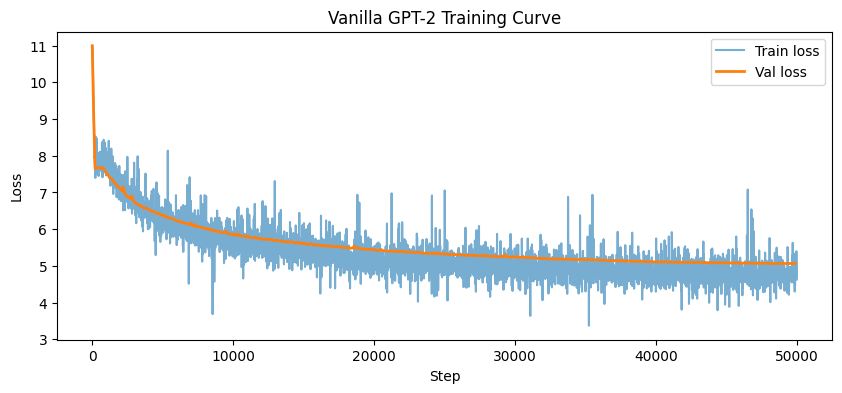

In [14]:
import matplotlib.pyplot as plt
import json

with open('/content/drive/MyDrive/vanilla_history.json') as f:
    history = json.load(f)

plt.figure(figsize=(10, 4))
plt.plot(history['train_steps'], history['train_loss'], label='Train loss', alpha=0.6)
plt.plot(history['val_steps'], history['val_loss'], label='Val loss', linewidth=2)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Vanilla GPT-2 Training Curve')
plt.savefig('/content/drive/MyDrive/vanilla_curve.png')
plt.show()

In [27]:
@torch.no_grad()
def generate_interleaved(model, prompt_tokens, max_new_tokens, device,
                         temperature=1.0, top_k=None):
    model.eval()
    skip_dist = model.config.lag_behind
    generated = list(prompt_tokens)
    target_len = len(prompt_tokens) + max_new_tokens

    def sample(logits):
        if temperature != 1.0:
            logits = logits / temperature
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            threshold = torch.topk(logits, k).values[-1]
            logits[logits < threshold] = float('-inf')
        return torch.multinomial(F.softmax(logits, dim=-1), 1).item()

    def run_model(tokens):
        seq  = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
        seq2 = seq.repeat(2, 1)
        logits_fwd, logits_lag, _ = model(seq2)
        return logits_fwd, logits_lag

    count_corr = 0
    while len(generated) < target_len:
        logits_fwd, logits_lag = run_model(generated)
        lag_pos = len(generated) - 1 - skip_dist

        next_token = sample(logits_fwd[0, -1, :].clone())
        generated.append(next_token)

        if lag_pos >= len(prompt_tokens):
            corrected = sample(logits_lag[0, -1, :].clone())
            if corrected != generated[lag_pos]:
                generated[lag_pos] = corrected
                count_corr += 1


    return generated, count_corr

In [3]:
def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)
    
    config    = checkpoint['config']
    model     = GPT2_Lag(config, device)
    optimizer = torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters() if p.dim() >= 2],
         "weight_decay": 0.1},
        {"params": [p for n, p in model.named_parameters() if p.dim() < 2],
         "weight_decay": 0.0}
    ], lr=3e-4, betas=(0.9, 0.95), eps=1e-8)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    model.to(device)

    print(f"Resumed from step {checkpoint['step']} | loss {checkpoint['loss']:.4f}")
    return model, optimizer, checkpoint['step'], checkpoint['history']

In [37]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')

prompt = "Once upon a time"
prompt_tokens = enc.encode(prompt)

output_tokens, count_corr = generate_interleaved(
    model, prompt_tokens, 
    max_new_tokens=100,
    device=device,
    temperature=0.8,
    top_k=50
)

print(enc.decode(output_tokens))
print(f"Total tokens generated: {len(output_tokens) - len(prompt_tokens)}")
print(f"Total corrections made: {count_corr}")

AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
